Dataset Count for each split.

In [1]:
import os

def count_images_in_dataset(dataset_path):
    counts = {}
    for split in ["train", "valid", "test"]:
        split_path = os.path.join(dataset_path, split, "images")
        if os.path.exists(split_path):
            img_count = len([f for f in os.listdir(split_path) if f.endswith(('.jpg', '.png', '.jpeg'))])
            counts[split] = img_count
        else:
            counts[split] = 0
    return counts

# Example usage:
dataset_path = r"F:\Data science pdf\SEM 3\Project_Mini\fire_smoke_dataset_new"  # change this
counts = count_images_in_dataset(dataset_path)
print("Dataset image counts:", counts)
print("Total images:", sum(counts.values()))


Dataset image counts: {'train': 13423, 'valid': 1277, 'test': 637}
Total images: 15337


Check the dataset format 

In [2]:
import os

# Path to your Roboflow dataset
DATASET_PATH = r"F:\Data science pdf\SEM 3\Project_Mini\fire_smoke_dataset_new" 

def check_labels():
    lbl_dir = os.path.join(DATASET_PATH, "train", "labels")
    img_dir = os.path.join(DATASET_PATH, "train", "images")

    # Check some label files
    label_files = [f for f in os.listdir(lbl_dir) if f.endswith(".txt")]
    print(f"Found {len(label_files)} label files in train/labels.")

    # Preview first 3 labels
    for lbl_file in label_files[:3]:
        path = os.path.join(lbl_dir, lbl_file)
        with open(path, "r") as f:
            lines = f.readlines()
        print(f"\n🔎 File: {lbl_file}")
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, x, y, w, h = parts
                print(f"  class={cls}, x={x}, y={y}, w={w}, h={h}")
            else:
                print("  ⚠️ Not YOLO format:", line.strip())

    # Check image formats
    img_files = os.listdir(img_dir)
    extensions = set([os.path.splitext(f)[1].lower() for f in img_files])
    print("\n📷 Image formats found:", extensions)

    # Check for YAML file
    yaml_path = os.path.join(DATASET_PATH, "data.yaml")
    if os.path.exists(yaml_path):
        print("\n✅ Found data.yaml:")
        with open(yaml_path, "r") as f:
            print(f.read())
    else:
        print("\n⚠️ data.yaml not found (but still okay).")

if __name__ == "__main__":
    check_labels()


Found 13423 label files in train/labels.

🔎 File: Frame_No0_video_15_jpg.rf.241134babd392a96c929f7888fc5327b.txt
  class=0, x=0.324765625, y=0.5303055555555556, w=0.026569661458333373, h=0.05468287037037027
  class=1, x=0.3367395833333333, y=0.42524074074074075, w=0.06094335937500001, h=0.11383217592592595

🔎 File: Frame_No0_video_15_jpg.rf.8853eca6e3e0359e31d367b86982602a.txt
  class=0, x=0.324765625, y=0.5303055555555556, w=0.026619791666666615, h=0.05505555555555559
  class=1, x=0.3367395833333333, y=0.42524074074074075, w=0.06098437499999996, h=0.11343518518518518

🔎 File: Frame_No0_video_15_jpg.rf.f49e26d1818174f9957be0dfc582a807.txt
  class=0, x=0.324765625, y=0.5303055555555556, w=0.026569661458333373, h=0.05468287037037027
  class=1, x=0.3367395833333333, y=0.42524074074074075, w=0.06094335937500001, h=0.11383217592592595

📷 Image formats found: {'.jpg'}

✅ Found data.yaml:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['fire', 'smoke']

roboflo

Checking the severity of the fire in each split(train, test and validtion) and each split into divided into mild, moderate and severe based on fire.

In [ ]:
import os
from PIL import Image

DATASET_PATH = r"F:\Data science pdf\SEM 3\Project_Mini\fire_smoke_dataset_new"

# Thresholds
MILD_THRESHOLD = 5
MODERATE_THRESHOLD = 20

def compute_fire_area_percentage(label_file, image_w, image_h):
    """
    Reads YOLO label file and computes total fire/smoke area %.
    """
    if not os.path.exists(label_file):
        return 0.0
    
    total_area = 0
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, x_center, y_center, w, h = map(float, parts)
            box_w = w * image_w
            box_h = h * image_h
            total_area += box_w * box_h

    img_area = image_w * image_h
    return (total_area / img_area) * 100 if img_area > 0 else 0.0

def preview_severity_distribution():
    splits = ["train", "valid", "test"]

    for split in splits:
        img_dir = os.path.join(DATASET_PATH, split, "images")
        lbl_dir = os.path.join(DATASET_PATH, split, "labels")

        counts = {"Mild": 0, "Moderate": 0, "Severe": 0}

        for img_file in os.listdir(img_dir):
            if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(img_dir, img_file)
            lbl_path = os.path.join(lbl_dir, os.path.splitext(img_file)[0] + ".txt")

            with Image.open(img_path) as img:
                w, h = img.size

            area_pct = compute_fire_area_percentage(lbl_path, w, h)

            # Assign severity
            if area_pct <= MILD_THRESHOLD:
                counts["Mild"] += 1
            elif area_pct <= MODERATE_THRESHOLD:
                counts["Moderate"] += 1
            else:
                counts["Severe"] += 1

        print(f"\n📊 {split.upper()} split distribution:")
        print(f"   Mild     : {counts['Mild']}")
        print(f"   Moderate : {counts['Moderate']}")
        print(f"   Severe   : {counts['Severe']}")

if __name__ == "__main__":
    preview_severity_distribution()



📊 TRAIN split distribution:
   Mild     : 2478
   Moderate : 6851
   Severe   : 4094

📊 VALID split distribution:
   Mild     : 244
   Moderate : 632
   Severe   : 401

📊 TEST split distribution:
   Mild     : 127
   Moderate : 326
   Severe   : 184


Creating the CNN dataset format using severity of the fire.

In [ ]:
import os
import shutil
from PIL import Image
DATASET_PATH = r"F:\Data science pdf\SEM 3\Project_Mini\fire_smoke_dataset_new" 

# Output path for CNN dataset
OUTPUT_PATH = r"F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN"

# Severity thresholds (new balanced version)
MILD_THRESHOLD = 5      # <=5% area
MODERATE_THRESHOLD = 20 # <=20% area
# Severe = >20% area


# =============================
# FUNCTION TO CALCULATE AREA %
# =============================
def compute_fire_area_percentage(label_file, image_w, image_h):
    """
    Reads YOLO label file and computes total fire/smoke area %.
    """
    if not os.path.exists(label_file):
        return 0.0
    
    total_area = 0
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, x_center, y_center, w, h = map(float, parts)
            box_w = w * image_w
            box_h = h * image_h
            total_area += box_w * box_h
    
    img_area = image_w * image_h
    return (total_area / img_area) * 100 if img_area > 0 else 0.0


# =============================
# MAIN PREPROCESSING
# =============================
def preprocess_dataset():
    splits = ["train", "valid", "test"]

    for split in splits:
        img_dir = os.path.join(DATASET_PATH, split, "images")
        lbl_dir = os.path.join(DATASET_PATH, split, "labels")

        if not os.path.exists(img_dir):
            print(f"Skipping missing split: {split}")
            continue

        # Create output directories
        for severity in ["Mild", "Moderate", "Severe"]:
            os.makedirs(os.path.join(OUTPUT_PATH, split, severity), exist_ok=True)

        # Counters for logging
        counts = {"Mild": 0, "Moderate": 0, "Severe": 0}

        # Process images
        for img_file in os.listdir(img_dir):
            if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(img_dir, img_file)
            lbl_path = os.path.join(lbl_dir, os.path.splitext(img_file)[0] + ".txt")

            # Open image to get dimensions
            with Image.open(img_path) as img:
                w, h = img.size

            # Compute fire/smoke area %
            area_pct = compute_fire_area_percentage(lbl_path, w, h)

            # Assign severity label
            if area_pct <= MILD_THRESHOLD:
                severity = "Mild"
            elif area_pct <= MODERATE_THRESHOLD:
                severity = "Moderate"
            else:
                severity = "Severe"

            counts[severity] += 1

            # Copy image into severity folder
            out_dir = os.path.join(OUTPUT_PATH, split, severity)
            shutil.copy(img_path, out_dir)

        print(f"✅ Finished processing {split} split.")
        print(f"📊 Distribution: Mild={counts['Mild']}, Moderate={counts['Moderate']}, Severe={counts['Severe']}")


if __name__ == "__main__":
    preprocess_dataset()
    print("New CNN dataset ready at:", OUTPUT_PATH)


✅ Finished processing train split.
📊 Distribution: Mild=2478, Moderate=6851, Severe=4094
✅ Finished processing valid split.
📊 Distribution: Mild=244, Moderate=632, Severe=401
✅ Finished processing test split.
📊 Distribution: Mild=127, Moderate=326, Severe=184
🎯 Preprocessing complete! New CNN dataset ready at: F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN


Check the new dataset looks perfect.

In [6]:
import os
from PIL import Image

BASE_PATH = r"F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN\train"
for severity in ["Mild", "Moderate", "Severe"]:
    folder = os.path.join(BASE_PATH, severity)
    print(f"\nChecking folder: {folder}")
    for img_file in os.listdir(folder)[:3]:  # check first 3 images
        img_path = os.path.join(folder, img_file)
        with Image.open(img_path) as img:
            print(f"{img_file}: size={img.size}")
            img.show()  # opens image for visual inspection



Checking folder: F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN\train\Mild
Frame_No0_video_15_jpg.rf.241134babd392a96c929f7888fc5327b.jpg: size=(1920, 1080)
Frame_No0_video_15_jpg.rf.8853eca6e3e0359e31d367b86982602a.jpg: size=(1920, 1080)
Frame_No0_video_15_jpg.rf.f49e26d1818174f9957be0dfc582a807.jpg: size=(1920, 1080)

Checking folder: F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN\train\Moderate
Frame_No0_video_19_jpg.rf.469edba42a2be3a4880ca089a6a14dc3.jpg: size=(1920, 1080)
Frame_No0_video_19_jpg.rf.736b40b23c0874ff6665cc5cedd6e215.jpg: size=(1920, 1080)
Frame_No0_video_19_jpg.rf.d82ec3ec3916284ea8be9481376f507b.jpg: size=(1920, 1080)

Checking folder: F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN\train\Severe
Frame_No0_video_5_jpg.rf.7ebd2d20e5a8d2d3fbfd15f8dbf2190b.jpg: size=(1920, 1080)
Frame_No0_video_5_jpg.rf.ca5baa49d4692587f9a60c87b25da33f.jpg: size=(1920, 1080)
Frame_No0_video_5_jpg.rf.f2de78f91e91686bdacddca3c1cafe6c.jpg: size=(1920

Check any duplicate images is present or not

In [7]:
import os
import hashlib

# Path to the dataset split you want to check
DATASET_SPLIT_PATH = r"F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN\train"

def hash_image(file_path):
    """Compute MD5 hash of an image file"""
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def find_duplicates(base_path):
    duplicates = {}
    total_files = 0

    for root, _, files in os.walk(base_path):
        for file in files:
            if not file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            total_files += 1
            file_path = os.path.join(root, file)
            h = hash_image(file_path)
            if h in duplicates:
                duplicates[h].append(file_path)
            else:
                duplicates[h] = [file_path]

    # Only keep hashes with more than 1 file (duplicates)
    dup_files = {h: paths for h, paths in duplicates.items() if len(paths) > 1}

    print(f"Total images scanned: {total_files}")
    print(f"Total unique images: {total_files - sum(len(v)-1 for v in dup_files.values())}")
    print(f"Total duplicate images: {sum(len(v)-1 for v in dup_files.values())}")
    
    # Optional: print duplicate file paths
    for h, paths in dup_files.items():
        print("\nDuplicate group:")
        for p in paths:
            print(" ", p)

    return dup_files

if __name__ == "__main__":
    duplicates = find_duplicates(DATASET_SPLIT_PATH)


Total images scanned: 13423
Total unique images: 13423
Total duplicate images: 0


Check the dataset is balanced or not

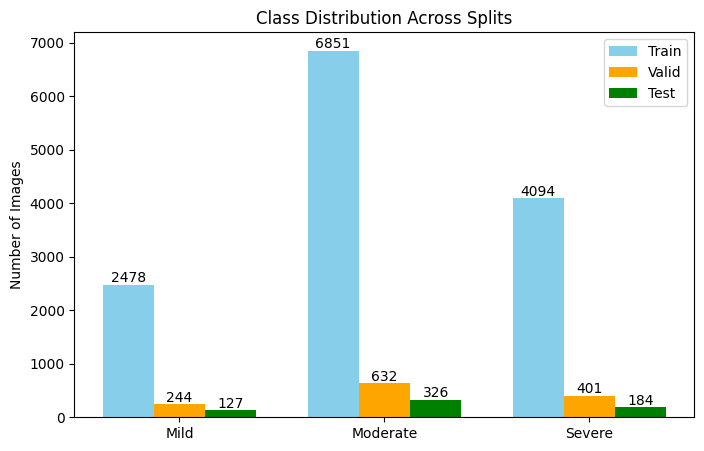

In [8]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Path to your CNN severity dataset
DATASET_PATH = r"F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN"

splits = ["train", "valid", "test"]
severities = ["Mild", "Moderate", "Severe"]

# Gather counts
all_counts = {}
for split in splits:
    split_path = os.path.join(DATASET_PATH, split)
    counts = []
    for severity in severities:
        folder = os.path.join(split_path, severity)
        if os.path.exists(folder):
            counts.append(len([f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]))
        else:
            counts.append(0)
    all_counts[split] = counts

# Plotting
x = np.arange(len(severities))  # Mild, Moderate, Severe
width = 0.25  # Width of bars

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(x - width, all_counts["train"], width, label="Train", color="skyblue")
ax.bar(x, all_counts["valid"], width, label="Valid", color="orange")
ax.bar(x + width, all_counts["test"], width, label="Test", color="green")

# Labels & title
ax.set_ylabel("Number of Images")
ax.set_title("Class Distribution Across Splits")
ax.set_xticks(x)
ax.set_xticklabels(severities)
ax.legend()

# Annotate counts above bars
for i in range(len(severities)):
    ax.text(i - width, all_counts["train"][i]+50, str(all_counts["train"][i]), ha='center')
    ax.text(i, all_counts["valid"][i]+50, str(all_counts["valid"][i]), ha='center')
    ax.text(i + width, all_counts["test"][i]+50, str(all_counts["test"][i]), ha='center')

plt.show()


Data Augmentation Applied for Mild class

📊 Image count per class: {'Moderate': 6851, 'Severe': 4094, 'Mild': 9912}


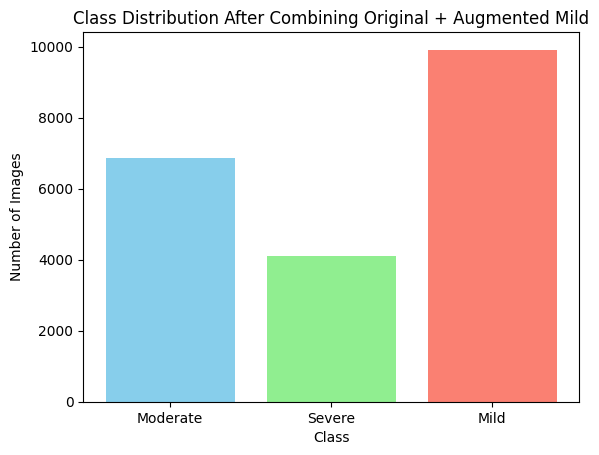

In [ ]:
import os
import matplotlib.pyplot as plt

# Paths
original_train = r"F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN\train"
augmented_mild = r"F:\Data science pdf\SEM 3\Project_Mini\augmented_data\Mild"

# Count Moderate & Severe from original dataset
class_counts = {}
for class_name in ["Moderate", "Severe"]:
    class_path = os.path.join(original_train, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Count Mild (original + augmented)
original_mild = len(os.listdir(os.path.join(original_train, "Mild")))
augmented_mild_count = len(os.listdir(augmented_mild))
class_counts["Mild"] = original_mild + augmented_mild_count

print("📊 Image count per class:", class_counts)

# Plot
plt.bar(class_counts.keys(), class_counts.values(), color=['skyblue','lightgreen','salmon'])
plt.title("Class Distribution After Combining Original + Augmented Mild")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


Balancing Mild , Moderate and Severe Class

In [1]:
import os
import cv2
import shutil
import random
import albumentations as A

# Paths
original_train = r"F:\Data science pdf\SEM 3\Project_Mini\severity_dataset_CNN\train"
balanced_output = r"F:\Data science pdf\SEM 3\Project_Mini\balanced_dataset_Augmented"

# Create output folders
for cls in ["Mild", "Moderate", "Severe"]:
    os.makedirs(os.path.join(balanced_output, cls), exist_ok=True)

# Copy original images first
for cls in ["Mild", "Moderate", "Severe"]:
    src = os.path.join(original_train, cls)
    dst = os.path.join(balanced_output, cls)
    for file in os.listdir(src):
        shutil.copy(os.path.join(src, file), dst)

# Count function
def count_images(folder):
    return len(os.listdir(folder))

# Initial counts
mild_count = count_images(os.path.join(balanced_output, "Mild"))
moderate_count = count_images(os.path.join(balanced_output, "Moderate"))
severe_count = count_images(os.path.join(balanced_output, "Severe"))

print(f"Before augmentation: Mild={mild_count}, Moderate={moderate_count}, Severe={severe_count}")

# Target counts (not exact equal, just close)
target_mild = 6000
target_severe = 5500

# Define augmentation pipeline (light augmentations to avoid overfitting)
transform = A.Compose([
    A.Rotate(limit=20, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=10, p=0.5),
])

def augment_class(class_name, target_count):
    folder = os.path.join(balanced_output, class_name)
    current_count = count_images(folder)

    if current_count >= target_count:
        print(f"{class_name} already has {current_count}, skipping augmentation.")
        return

    print(f"Augmenting {class_name} from {current_count} → {target_count}...")
    files = os.listdir(folder)
    i = 0
    while current_count < target_count:
        img_path = os.path.join(folder, random.choice(files))
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        augmented = transform(image=image)
        aug_img = augmented["image"]

        save_path = os.path.join(folder, f"aug_{i}.jpg")
        cv2.imwrite(save_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

        current_count += 1
        i += 1

# Augment Mild and Severe only
augment_class("Mild", target_mild)
augment_class("Severe", target_severe)

# Final counts
mild_count = count_images(os.path.join(balanced_output, "Mild"))
moderate_count = count_images(os.path.join(balanced_output, "Moderate"))
severe_count = count_images(os.path.join(balanced_output, "Severe"))

print(f"✅ After balancing: Mild={mild_count}, Moderate={moderate_count}, Severe={severe_count}")


Before augmentation: Mild=2478, Moderate=6851, Severe=4094
Augmenting Mild from 2478 → 6000...


c:\Python311\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Augmenting Severe from 4094 → 5500...
✅ After balancing: Mild=6000, Moderate=6851, Severe=5500


Bar Plot of the 3 Classes

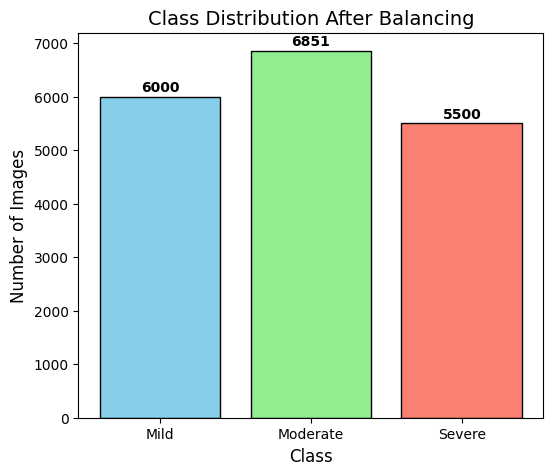

In [2]:
import matplotlib.pyplot as plt

# Final counts after balancing
class_counts = {
    "Mild": 6000,
    "Moderate": 6851,
    "Severe": 5500
}

# Plot
plt.figure(figsize=(6,5))
plt.bar(class_counts.keys(), class_counts.values(), color=['skyblue','lightgreen','salmon'], edgecolor="black")

# Labels & Title
plt.title("Class Distribution After Balancing", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

# Add values on top of bars
for i, (cls, count) in enumerate(class_counts.items()):
    plt.text(i, count + 100, str(count), ha='center', fontsize=10, fontweight="bold")

plt.show()
